# Task 1 — Initial EDA: Brent Crude Oil Prices

This notebook covers the exploratory data analysis (EDA) portion of Task 1:
loading the Brent price series, inspecting trend and volatility, testing for
stationarity, and overlaying the compiled event dataset.

**Data sources**
- `data/raw/BrentOilPrices.csv` — daily Brent spot price (USD/barrel), sourced from the
  US EIA via the FRED `DCOILBRENTEU` series. 
- `data/raw/brent_oil_key_events.csv` — 17 major geopolitical/OPEC/economic events (Task 1 deliverable).

In [4]:
import sys
from pathlib import Path

# Robustly locate the project's src/ folder regardless of where Jupyter's
# working directory happens to be (notebooks/ folder, project root, etc.)
# by walking upward from the current directory until we find it.
def _find_src_dir(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        src_candidate = candidate / "src"
        if (src_candidate / "data_loader.py").exists():
            return src_candidate
    raise FileNotFoundError(
        "Could not locate the project's src/ directory by walking up from "
        f"{start}. Make sure you're running this notebook from within the "
        "project folder."
    )

src_dir = _find_src_dir(Path.cwd())
sys.path.insert(0, str(src_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from data_loader import load_brent_prices, load_events, add_log_returns
from eda import (
    summarize_stationarity,
    rolling_volatility,
    basic_descriptive_stats,
    year_over_year_trend,
)

plt.rcParams["figure.figsize"] = (11, 4.5)
pd.set_option("display.max_columns", None)

## 1. Load and inspect the data

In [5]:
prices = load_brent_prices()
prices = add_log_returns(prices)

print(f"Rows: {len(prices):,}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")
prices.head()

c:\Users\loolt\Brent_Oil_Price_Analysis\src\data_loader.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


Rows: 9,011
Date range: 1987-05-20 to 2022-11-14


,Price,log_price,log_return
Date,,,
1987-05-20,18.63,2.924773,NaN
1987-05-21,18.45,2.915064,-0.009709
1987-05-22,18.55,2.920470,0.005405
1987-05-25,18.60,2.923162,0.002692
1987-05-26,18.63,2.924773,0.001612


In [6]:
# Missing values / basic integrity check
print(prices[["Price"]].isna().sum())
print("\nDuplicate dates:", prices.index.duplicated().sum())
prices["Price"].describe()

Price    0
dtype: int64

Duplicate dates: 0


count    9011.000000
mean       48.420782
std        32.860110
min         9.100000
25%        19.050000
50%        38.570000
75%        70.090000
max       143.950000
Name: Price, dtype: float64

## 2. Trend analysis

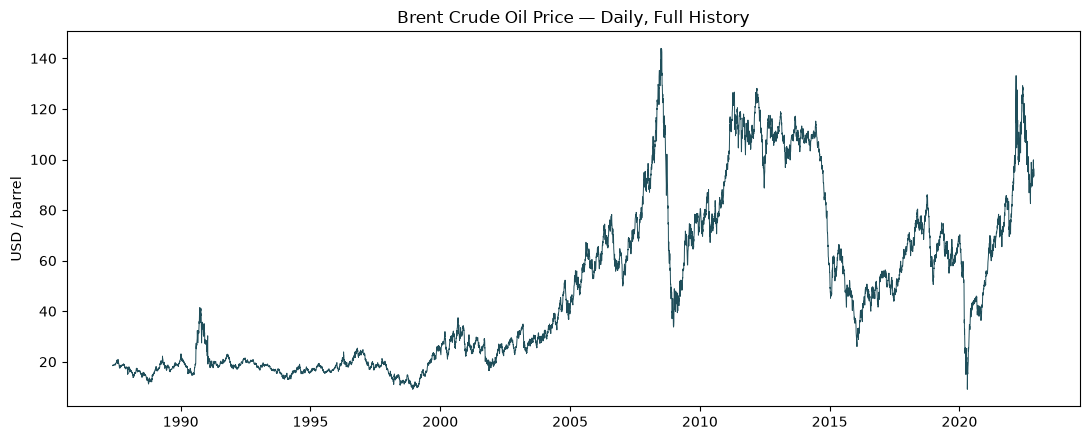

In [7]:
fig, ax = plt.subplots()
ax.plot(prices.index, prices["Price"], linewidth=0.7, color="#1F4E5A")
ax.set_title("Brent Crude Oil Price — Daily, Full History")
ax.set_ylabel("USD / barrel")
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

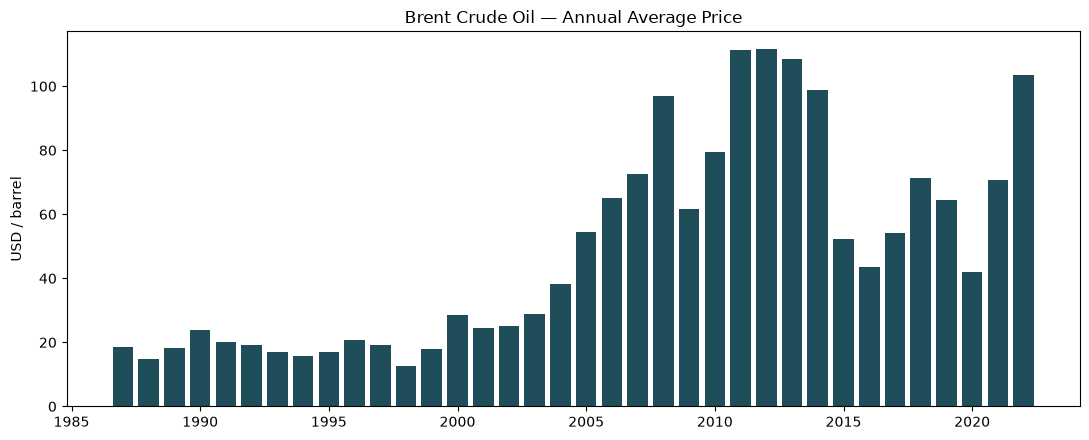

In [8]:
annual = year_over_year_trend(prices["Price"])
fig, ax = plt.subplots()
ax.bar(annual.index.year, annual.values, color="#1F4E5A")
ax.set_title("Brent Crude Oil — Annual Average Price")
ax.set_ylabel("USD / barrel")
plt.tight_layout()
plt.show()

**Observation:** The price level does not follow a single smooth trend. Instead it
moves through distinct regimes — a low, stable range through the late 1990s, a strong
run-up to the 2008 peak, a sharp collapse, a partial recovery, the 2014-2016 decline,
the 2020 COVID-19 collapse, and the 2022 spike following Russia's invasion of Ukraine.
This regime-like behavior is exactly what change point models are designed to capture.

## 3. Stationarity testing

In [9]:
stationarity_table = summarize_stationarity(prices["Price"], prices["log_return"])
stationarity_table

c:\Users\loolt\Brent_Oil_Price_Analysis\src\eda.py:46: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, _, crit_vals = kpss(series, regression=regression, nlags="auto")
c:\Users\loolt\Brent_Oil_Price_Analysis\src\eda.py:46: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, _, crit_vals = kpss(series, regression=regression, nlags="auto")


,series,ADF statistic,ADF p-value,ADF conclusion,KPSS statistic,KPSS p-value,KPSS conclusion
0,Price level,-1.9939,0.2893,Non-stationary,9.5588,0.01,Non-stationary
1,Log return,-16.4271,0.0000,Stationary,0.0343,0.10,Stationary


**Interpretation:**
- **ADF** (null hypothesis: unit root / non-stationary): fails to reject the null for the
  raw price level (large negative statistic not exceeded), but strongly rejects it for
  log returns.
- **KPSS** (null hypothesis: stationary): rejects stationarity for the raw price level, but
  is consistent with stationarity for log returns.

Both tests agree: **the raw price level is non-stationary, while log returns are (approximately)
stationary.** This is the standard justification for modeling returns — or shifts in their
mean/variance — rather than modeling the raw price level directly.

## 4. Volatility patterns

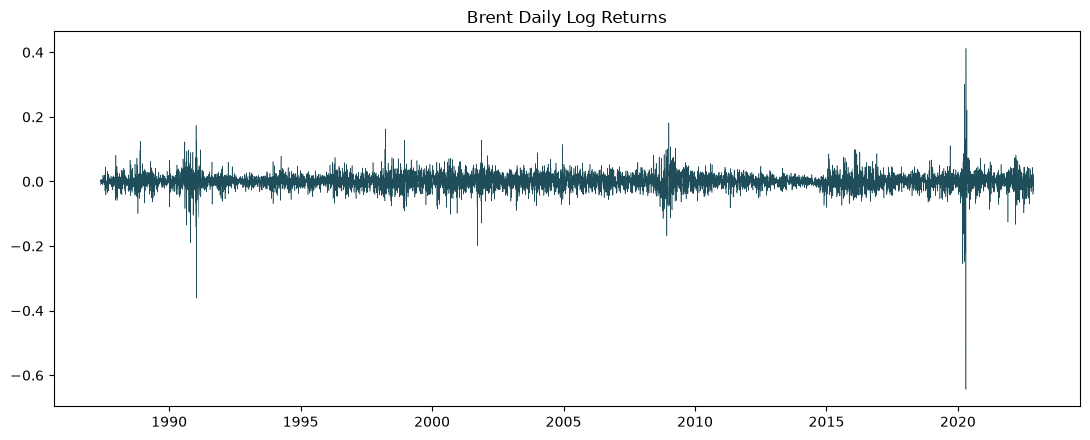

In [10]:
fig, ax = plt.subplots()
ax.plot(prices.index, prices["log_return"], linewidth=0.4, color="#1F4E5A")
ax.set_title("Brent Daily Log Returns")
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

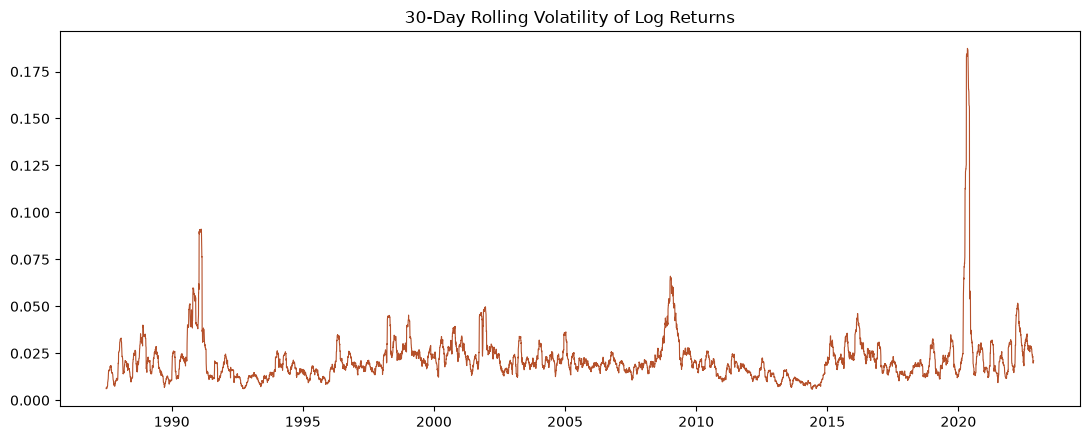

In [11]:
vol_30d = rolling_volatility(prices["log_return"], window=30)
fig, ax = plt.subplots()
ax.plot(prices.index, vol_30d, linewidth=0.8, color="#B5502A")
ax.set_title("30-Day Rolling Volatility of Log Returns")
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

In [12]:
basic_descriptive_stats(prices["log_return"])

count       9010.000000
mean           0.000179
std            0.025532
min           -0.643699
25%           -0.011154
50%            0.000402
75%            0.012127
max            0.412023
skew          -1.744406
kurtosis      65.904723
Name: log_return, dtype: float64

**Observation:** Returns show clear **volatility clustering** — quiet stretches (mid-1990s,
mid-2010s low-vol period) alternate with turbulent ones (2008-09, early 2020). The return
distribution is also strongly non-normal: heavy negative skew and very high kurtosis, i.e.
fat tails with occasional extreme daily moves (e.g., the 2020 COVID-19 demand shock).
This confirms that a constant-variance model is inappropriate — models allowing for
regime-dependent variance (or explicit change points in volatility) are needed.

## 5. Overlaying compiled events

In [13]:
events = load_events()
events.head(17)

,event_id,start_date,event_name,category,region,description,expected_direction
0,1,1990-08-02,Iraqi invasion of Kuwait,Geopolitical Conflict,Middle East,"Iraq invaded Kuwait, removing a major OPEC pro...",Increase
1,2,1991-01-17,Gulf War / Operation Desert Storm begins,Geopolitical Conflict,Middle East,A US-led coalition launched military action to...,"Increase (short-term spike, then decline)"
2,3,1997-07-02,Asian Financial Crisis begins,Economic Shock,Asia,The collapse of the Thai baht triggered a regi...,Decrease
3,4,1998-03-01,OPEC production cut agreement,OPEC Decision,Global,Facing a price collapse from oversupply and we...,Increase
4,5,2001-09-11,September 11 terrorist attacks,Geopolitical Conflict,North America,The attacks on the United States created short...,Decrease (short-term)
5,6,2003-03-20,US-led invasion of Iraq,Geopolitical Conflict,Middle East,The invasion raised concerns about disruption ...,Increase
6,7,2008-07-11,Brent crude reaches record high (~$147/barrel),Market Price Extreme,Global,"Brent prices peaked amid strong global demand,...",Peak / reversal point
7,8,2008-09-15,Collapse of Lehman Brothers / Global Financial...,Economic Shock,Global,The onset of the global financial crisis cause...,Decrease
8,9,2010-12-18,Onset of the Arab Spring,Geopolitical Conflict,Middle East & North Africa,Widespread political uprisings across MENA cou...,Increase
9,10,2011-02-17,Libyan Civil War erupts,Geopolitical Conflict,North Africa,Civil conflict in Libya sharply curtailed the ...,Increase


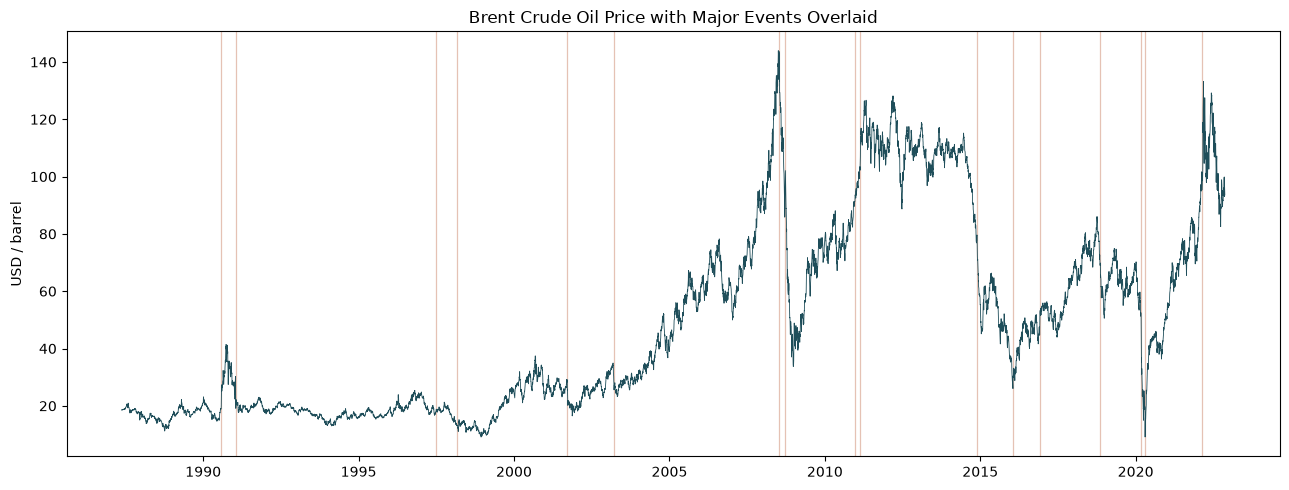

In [14]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(prices.index, prices["Price"], linewidth=0.6, color="#1F4E5A", zorder=1)

for _, row in events.iterrows():
    ax.axvline(row["start_date"], color="#B5502A", alpha=0.35, linewidth=0.9, zorder=0)

ax.set_title("Brent Crude Oil Price with Major Events Overlaid")
ax.set_ylabel("USD / barrel")
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

**Note:** these vertical lines mark *documented* event dates for visual reference only.
Coincidence in timing between an event line and a price move is **not**, on its own,
evidence of causation — see the assumptions/limitations discussion in the Task 1 report
for why this distinction matters before drawing conclusions in later tasks.

## 6. Summary of initial EDA findings

- **Trend:** Brent prices move through distinct multi-year regimes rather than a single
  smooth trend, consistent with the need for a change point (structural break) approach.
- **Stationarity:** the raw price level is non-stationary (unit root); log returns are
  approximately stationary. Downstream modeling should operate on returns (or rolling
  statistics of returns) rather than raw price levels.
- **Volatility:** returns exhibit clear volatility clustering and fat tails, so any change
  point model should allow for shifts in variance, not just in mean.
- **Next step (Task 2):** fit a Bayesian change point model to the return series to
  identify probable structural break dates, then cross-reference them against the
  compiled event log — treating any alignment as a plausible association rather than
  proven causation.